In [1]:
import sys
!{sys.executable} -m pip install git+https://github.com/facebookresearch/segment-anything.git
!{sys.executable} -m pip install opencv-python pillow matplotlib

  Cloning https://github.com/facebookresearch/segment-anything.git to C:\Users\Админ\AppData\Local\Temp\pip-req-build-3agj6622
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\Админ\AppData\Local\Temp\pip-req-build-3agj6622'


In [1]:
%pip list

Package                   Version
------------------------- ------------
absl-py                   2.4.0
accelerate                1.13.0
addict                    2.4.0
annotated-doc             0.0.4
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.4
click                     8.3.1
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.2
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
diffusers                 0.37.0
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema   

In [2]:
!{sys.executable} -m pip install groundingdino-py

In [4]:
%pip list

Package                   Version
------------------------- ------------
absl-py                   2.4.0
accelerate                1.13.0
addict                    2.4.0
annotated-doc             0.0.4
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.4
click                     8.3.1
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.2
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
diffusers                 0.37.0
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema   

In [3]:
!{sys.executable} -m pip install "transformers==4.30.2"

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 43.7 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 36.7 MB/s  0:00:00
   ---------------------------------------- 0.0/566.4 kB ? eta -:--:--
   ---------------------------------------- 566.4/566.4 kB ?  0:00:00
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 3.5/3.5 MB 41.1 MB/s  0:00:00

  Attempting uninstall: tokenizers

    Found existing installation: tokenizers 0.22.2

    Uninstalling tokenizers-0.22.2:

      Successfully uninstalled tokenizers-0.22.2

  Attempting uninstall: huggingface-hub

    Found existing installation: huggingface_hub 1.6.0

   ------------- -------------------------- 1/3 [huggingface-hub]
    Uninstalling huggingface_hub-1.6.0:
   ------------- -------------------------- 1/3 [huggingface-hub]
      Successfully uninstalled huggingface_hub-1.6.

In [1]:
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import requests
from huggingface_hub import hf_hub_url
from tqdm import tqdm

In [2]:
# параметры модели
repo_id = "ShilongLiu/GroundingDINO"
filename = "groundingdino_swinb_cogcoor.pth"

# путь для сохранения (текущая папка)
save_path = Path(filename)

# получаем прямую ссылку на файл
file_url = hf_hub_url(repo_id=repo_id, filename=filename)
print("Downloading from:", file_url)

# скачиваем потоково
response = requests.get(file_url, stream=True)
response.raise_for_status()

total_size = int(response.headers.get("content-length", 0))

with open(save_path, "wb") as f:
    with tqdm(total=total_size, unit="B", unit_scale=True, desc=filename) as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

print("Saved to:", save_path.resolve())

groundingdino_swinb_cogcoor.pth: 100%|██████████| 938M/938M [00:14<00:00, 66.5MB/s] 

Saved to: C:\Users\Админ\Desktop\py\DataScince\NN\learning\groundingdino_swinb_cogcoor.pth


In [3]:
from groundingdino.util.inference import Model as GroundingDINO
from segment_anything import sam_model_registry, SamPredictor

C:\Users\Админ\Desktop\NN_1\nn_env\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
# путь к файлу GroundingDINO, который ты скачал
grounding_checkpoint = r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\groundingdino_swinb_cogcoor.pth"

In [6]:
# куда сохраняем конфиг
config_path = Path("GroundingDINO_SwinB.cfg.py")

# скачиваем, если нет
if not config_path.exists():
    url = hf_hub_url(
        repo_id="ShilongLiu/GroundingDINO",
        filename="GroundingDINO_SwinB.cfg.py"
    )
    print("Downloading config:", url)

    text = requests.get(url).text

    with open(config_path, "w", encoding="utf-8") as f:
        f.write(text)

    print("Saved:", config_path.resolve())

In [8]:
# 3) загружаем модель
dino = GroundingDINO(
    model_config_path=str(config_path),
    model_checkpoint_path=grounding_checkpoint,
    device=device
)

final text_encoder_type: bert-base-uncased


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [11]:
# 2) Загружаем SAM
sam_checkpoint = r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\sam_vt_h.pth"
sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint).to(device)
sam_predictor = SamPredictor(sam)

C:\Users\Админ\Desktop\NN_1\nn_env\lib\site-packages\segment_anything\build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


In [12]:
# 3) Загружаем изображение
image_path = r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\horse.jpg"
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [14]:
# 4) Ищем лошадь — распаковываем в две переменные
detections, phrases = dino.predict_with_caption(
    img_rgb,
    caption="horse",
    box_threshold=0.3,
    text_threshold=0.25
)

# Теперь вы можете получить доступ к данным через объект detections
print("Found boxes:", detections.xyxy.shape) # Координаты боксов
print("Confidence scores:", detections.confidence) # Логиты (уверенность)
print("Phrases:", phrases)

Found boxes: (2, 4)
Confidence scores: [0.47006816 0.33331457]
Phrases: ['horse', 'horse']


In [15]:
# На всякий случай проверьте перед запуском:
print(f"SAM device: {sam_predictor.device}")

SAM device: cuda:0


Mask saved to: C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\horse_mask_refined.png


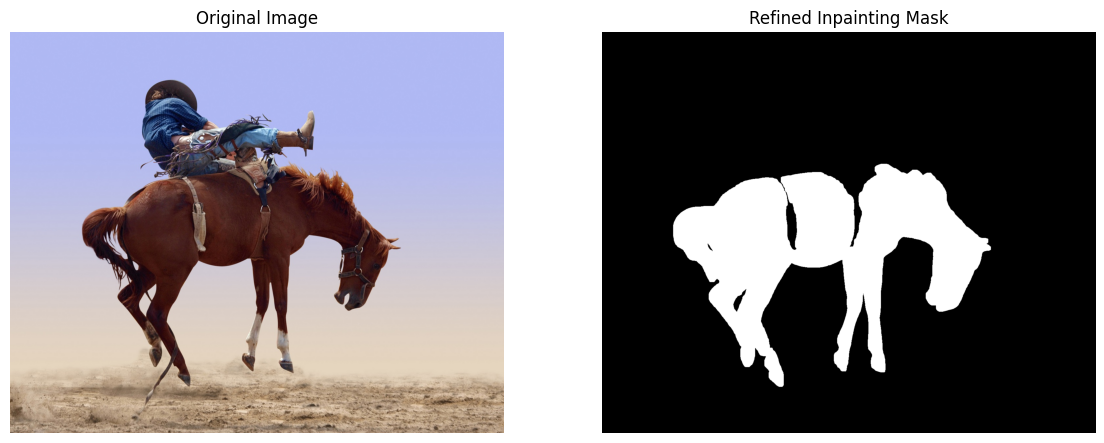

In [16]:
# 5) Берём координаты первого бокса из объекта detections
# .xyxy[0] — это массив [x1, y1, x2, y2] в пикселях
box = detections.xyxy[0]

# 6) Запускаем SAM
sam_predictor.set_image(img_rgb)
masks, scores, _ = sam_predictor.predict(
    box=box,
    multimask_output=True
)

# 7) Выбираем маску с самым высоким баллом уверенности
mask = masks[np.argmax(scores)] # Маска типа bool (True/False)

# --- ДОПОЛНЕНИЕ: Улучшение маски для Inpainting ---
# Превращаем в uint8 (0 или 255)
mask_uint8 = (mask.astype(np.uint8) * 255)

# Немного расширим маску (на 5-10 пикселей), чтобы "захватить" края объекта
kernel = np.ones((10, 10), np.uint8)
mask_refined = cv2.dilate(mask_uint8, kernel, iterations=1)
# --------------------------------------------------

# 8) Подготовка финальных версий
# mask_refined — лошадь БЕЛАЯ (обычно нужно для SD)
# mask_inverted — лошадь ЧЕРНАЯ (если того требует ваш софт)
mask_inverted = cv2.bitwise_not(mask_refined)

# 9) Сохраняем результат
mask_image = Image.fromarray(mask_refined) # Сохраняем "белую" лошадь
output_mask_path = r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\horse_mask_refined.png"
mask_image.save(output_mask_path)

print(f"Mask saved to: {output_mask_path}")

# 10) Визуализация
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
# Показываем маску (белое — это то, что будет закрашено)
plt.imshow(mask_refined, cmap="gray")
plt.title("Refined Inpainting Mask")
plt.axis("off")
plt.show()